# Multimodal Keratoconus Detection — CornOrb

This notebook implements a multimodal deep learning framework for binary keratoconus (KC) classification using the [CornOrb dataset](https://doi.org/10.5281/zenodo.17127265) — one of the first large-scale Orbscan 3 corneal topography resources from Africa.

**Architecture:** A dual-branch late-fusion network (**MultimodalFusionNet**) jointly processes:
- **Image branch:** Four Orbscan corneal maps (Axial, Anterior, Posterior, Pachymetry) via a pretrained ResNet-18 backbone
- **Clinical branch:** Seven structured biomarkers (age, astigmatism, Kmax, pachymetry, asphericity) via a lightweight MLP

**Ablation study** compares three variants: `image_only`, `clinical_only`, and `fused`.

> All implementation code lives in the repo modules (`data/`, `models/`, `training/`, `evaluation/`). This notebook is a thin orchestration layer — configure and run.

## 0. Setup

Clone the repository and install `grad-cam` — the only dependency not pre-installed on Google Colab. All other required libraries (`torch`, `torchvision`, `scikit-learn`, `pandas`, `numpy`, `matplotlib`, `seaborn`, `Pillow`) are available by default.

In [1]:
# Clone repo and install the only missing dependency
!git clone https://github.com/Aghaei-Amirmasoud/CornOrb-Multimodal-KC.git
%cd CornOrb-Multimodal-KC
!pip install -q grad-cam


Cloning into 'CornOrb-Multimodal-KC'...
remote: Enumerating objects: 62, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 62 (delta 3), reused 8 (delta 3), pack-reused 53 (from 1)
Receiving objects: 100% (62/62), 172.63 MiB | 25.75 MiB/s, done.
Resolving deltas: 100% (3/3), done.
Updating files: 100% (46/46), done.
/content/CornOrb-Multimodal-KC
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 77.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
import sys
sys.path.insert(0, ".")
from config import *
set_seed()
print(f"Device: {DEVICE}")
print(f"Clinical cols: {CLINICAL_COLS}")


Device: cuda
Clinical cols: ['age_years', 'astig_value_D', 'kmax_value_D', 'pachy_central_um', 'pachy_thinnest_um', 'asphericity_anterior', 'asphericity_posterior']


## 1. Load Dataset

The CornOrb dataset is hosted on Zenodo (DOI: [10.5281/zenodo.17127265](https://doi.org/10.5281/zenodo.17127265)) and comprises 1,454 eyes from 744 patients, including four Orbscan corneal maps per eye and a structured clinical annotation CSV.

Set `DATA_SOURCE` below:
- `'zenodo'` — downloads the CSV and image ZIP directly from Zenodo (~680 MB, ~2 min on Colab T4). Skips if already downloaded.
- `'drive'` — copies from Google Drive (faster if already uploaded). Update `DRIVE_CSV` and `DRIVE_ZIP` in `config.py` to match your Drive layout.

In [3]:
from data.download import load_data

DATA_SOURCE = "drive"   # change to "zenodo" to download from Zenodo
load_data(source=DATA_SOURCE)


Mounted at /content/drive
CSV copied from Drive → /content/CornOrb-Multimodal-KC/dataset/clinical_data_and_labels.csv
Extracting ZIP from Drive ...
Extracted.
Dataset ready.
  CSV   : /content/CornOrb-Multimodal-KC/dataset/clinical_data_and_labels.csv
  Images: /content/CornOrb-Multimodal-KC/dataset/ORBSCAN_Dataset


## 2. Imports & EDA

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.multitest import multipletests


In [5]:
df = pd.read_csv(CSV_PATH)
print(f"Shape: {df.shape}")
print("\nClass distribution:")
print(df["label"].value_counts())
df.head()


Shape: (1454, 17)

Class distribution:
label
0    889
1    565
Name: count, dtype: int64


,patient_code,eye,age_years,gender,astig_value_D,astig_axis_deg,kmax_value_D,kmax_axis_deg,pachy_central_um,pachy_thinnest_um,pachy_thinnest_x,pachy_thinnest_y,asphericity_anterior,asphericity_posterior,label,split_80_20,fold
0,63358,OS,41,m,-2.2,156,45.5,66,530,514,1.1,-0.9,-0.19,0.08,0,test,NaN
1,UAXDY,OS,30,f,-1.5,6,44.0,96,517,514,0.0,0.5,-0.29,-0.29,0,train,1.0
2,MF9GX,OD,23,m,-2.2,10,43.2,100,528,525,1.5,0.0,-0.25,2.21,0,train,2.0
3,XDKSU,OD,30,f,-2.0,28,46.5,118,541,532,-0.3,-0.5,-0.25,-0.28,0,train,5.0
4,DF14Z,OD,29,f,-2.2,139,41.6,49,544,534,-1.7,-0.5,-0.17,0.20,0,test,NaN


### 2.1 Class and Sex Distribution

Visualize the diagnostic label distribution and sex breakdown across the dataset, both overall and stratified by diagnosis.

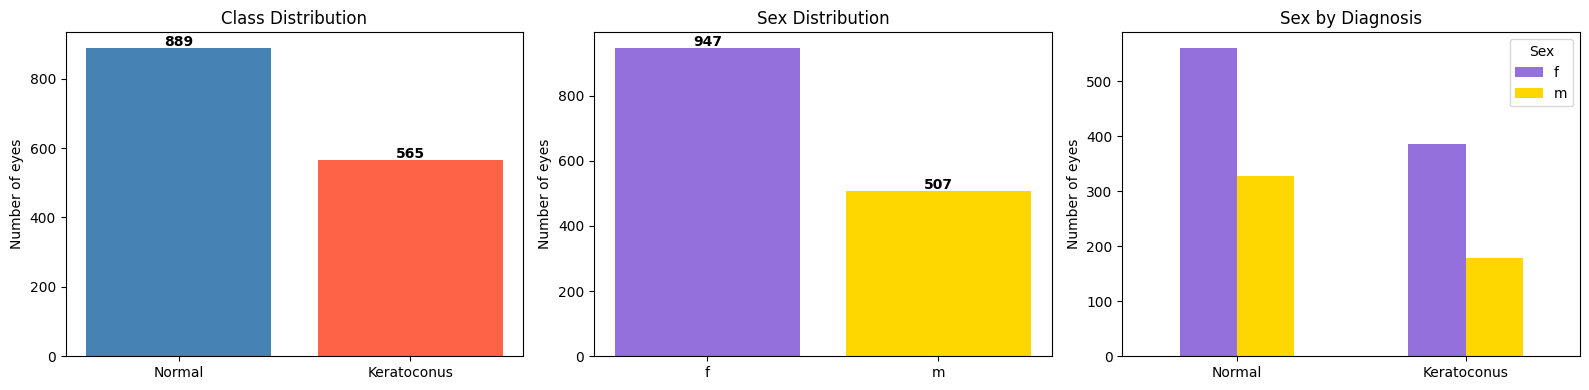

In [6]:
# ── Class balance + sex distribution ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

counts = df["label"].value_counts()
axes[0].bar(["Normal", "Keratoconus"], counts.values, color=["steelblue", "tomato"])
axes[0].set_title("Class Distribution"); axes[0].set_ylabel("Number of eyes")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha="center", fontweight="bold")

sex_counts = df["gender"].value_counts()
axes[1].bar(sex_counts.index.astype(str), sex_counts.values, color=["mediumpurple", "gold"])
axes[1].set_title("Sex Distribution"); axes[1].set_ylabel("Number of eyes")
for i, v in enumerate(sex_counts.values):
    axes[1].text(i, v + 5, str(v), ha="center", fontweight="bold")

sex_by_label = df.groupby(["label", "gender"]).size().unstack(fill_value=0)
sex_by_label.index = ["Normal", "Keratoconus"]
sex_by_label.plot(kind="bar", ax=axes[2], color=["mediumpurple", "gold"])
axes[2].set_title("Sex by Diagnosis"); axes[2].set_ylabel("Number of eyes")
axes[2].set_xlabel(""); axes[2].legend(title="Sex"); axes[2].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/eda_class_sex.png", dpi=150)
plt.show()


### 2.2 Clinical Variable Distributions

Box plots comparing all seven clinical biomarkers between Normal and Keratoconus eyes.

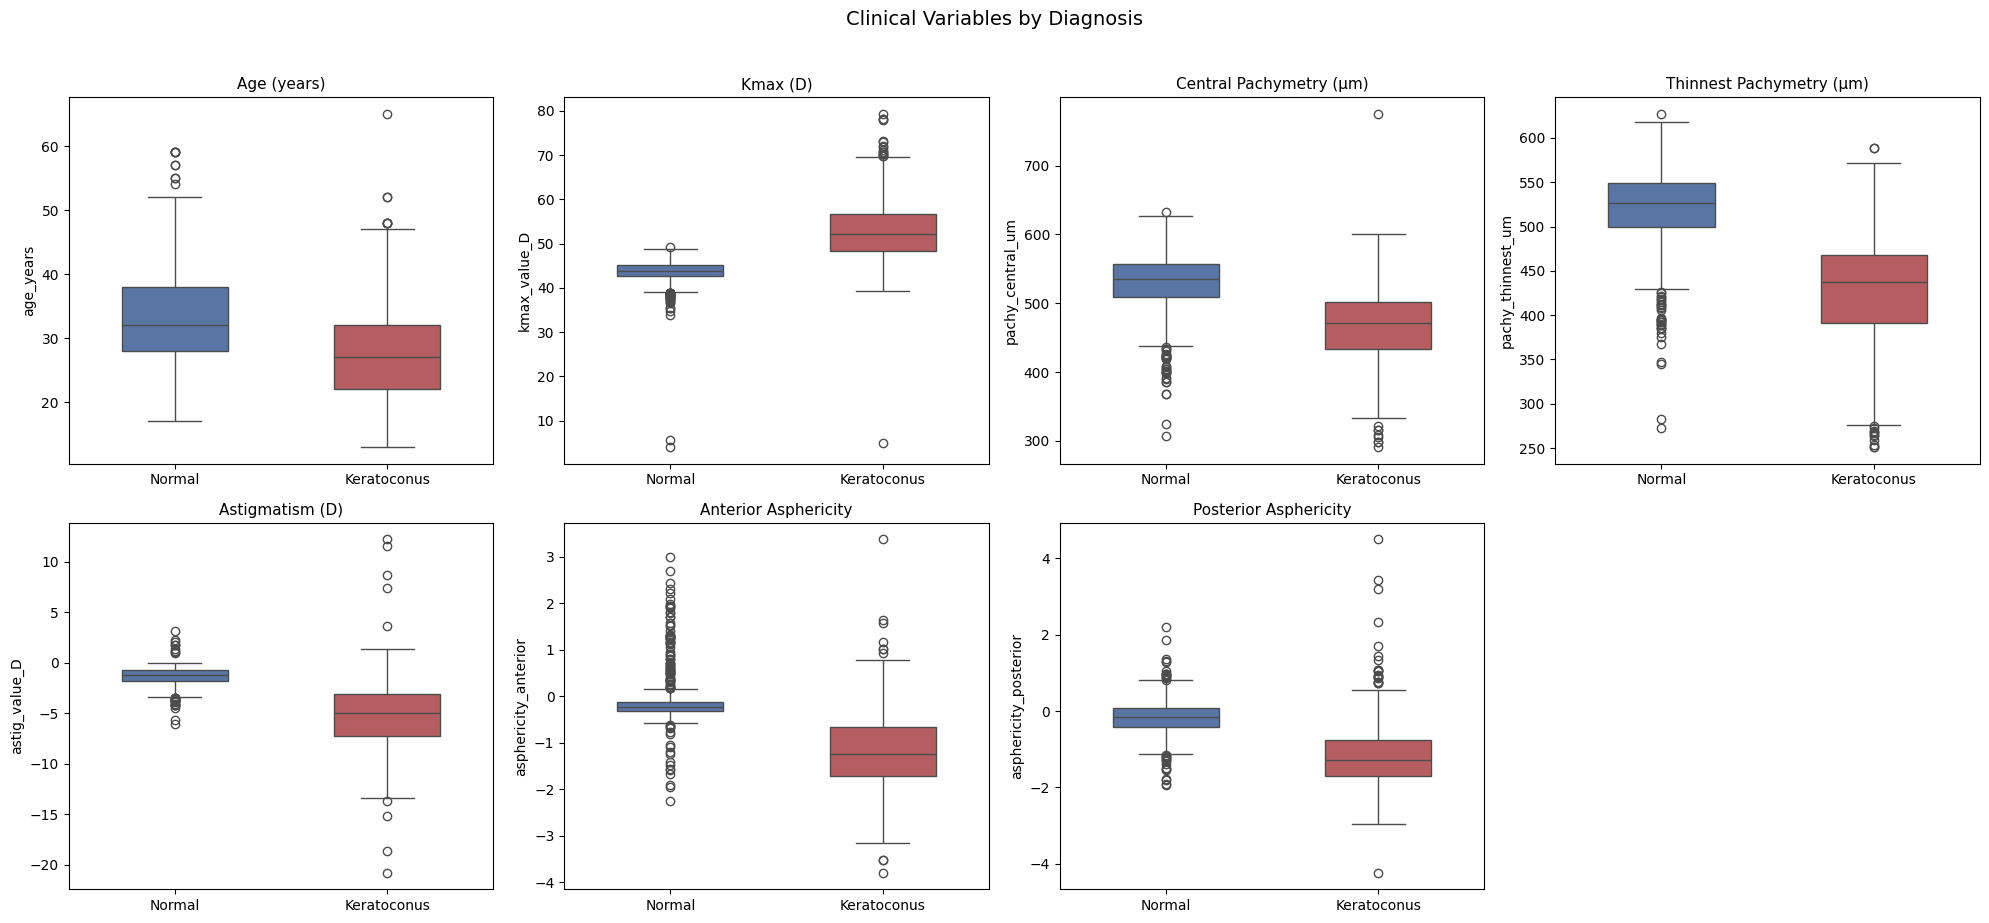

In [7]:
# ── Box plots: clinical variables by diagnosis ────────────────────────────────
box_vars = {
    "age_years": "Age (years)", "kmax_value_D": "Kmax (D)",
    "pachy_central_um": "Central Pachymetry (µm)",
    "pachy_thinnest_um": "Thinnest Pachymetry (µm)",
    "astig_value_D": "Astigmatism (D)",
    "asphericity_anterior": "Anterior Asphericity",
    "asphericity_posterior": "Posterior Asphericity",
}
n_cols = 4
n_rows = int(np.ceil(len(box_vars) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4.5*n_rows))
axes = axes.flatten()
palette = {0: "#4C72B0", 1: "#C44E52"}
for idx, (col, label) in enumerate(box_vars.items()):
    sns.boxplot(data=df, x="label", y=col, hue="label",
                palette=palette, legend=False, ax=axes[idx], width=0.5)
    axes[idx].set_xticks([0,1]); axes[idx].set_xticklabels(["Normal","Keratoconus"])
    axes[idx].set_xlabel(""); axes[idx].set_title(label, fontsize=11)
for idx in range(len(box_vars), len(axes)):
    axes[idx].axis("off")
plt.suptitle("Clinical Variables by Diagnosis", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/clinical_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()


### 2.3 Summary Statistics Table (Table 2)

Mean ± standard deviation for each clinical variable stratified by diagnosis, with Benjamini-Hochberg corrected p-values (Welch's t-test) to account for multiple comparisons across the seven variables.

In [8]:
# ── Table 2: Summary statistics with BH-adjusted p-values ────────────────────
table2_vars = {
    "age_years": "Age (years)", "pachy_central_um": "Central pachymetry (µm)",
    "pachy_thinnest_um": "Thinnest pachymetry (µm)", "kmax_value_D": "Kmax (D)",
    "astig_value_D": "Astigmatism (D)", "asphericity_anterior": "Anterior asphericity",
    "asphericity_posterior": "Posterior asphericity",
}
rows, pvals = [], []
for col, label in table2_vars.items():
    n_vals = df.loc[df["label"]==0, col].dropna()
    k_vals = df.loc[df["label"]==1, col].dropna()
    _, p = stats.ttest_ind(n_vals, k_vals, equal_var=False)
    pvals.append(p)
    rows.append({"Variable": label,
                 f"Normal (n={len(n_vals)})": f"{n_vals.mean():.1f} ± {n_vals.std():.1f}",
                 f"Keratoconus (n={len(k_vals)})": f"{k_vals.mean():.1f} ± {k_vals.std():.1f}"})
_, pvals_adj, _, _ = multipletests(pvals, alpha=0.05, method="fdr_bh")
for i, row in enumerate(rows):
    row["pBH"] = "< 0.001" if pvals_adj[i] < 0.001 else f"{pvals_adj[i]:.3f}"
table2_df = pd.DataFrame(rows)
table2_df


,Variable,Normal (n=889),Keratoconus (n=565),pBH
0,Age (years),33.5 ± 7.4,27.9 ± 7.1,< 0.001
1,Central pachymetry (µm),530.4 ± 42.9,464.7 ± 53.9,< 0.001
2,Thinnest pachymetry (µm),520.7 ± 44.2,427.5 ± 59.2,< 0.001
3,Kmax (D),43.7 ± 2.9,53.1 ± 6.9,< 0.001
4,Astigmatism (D),-1.3 ± 0.9,-5.3 ± 3.3,< 0.001
5,Anterior asphericity,-0.1 ± 0.5,-1.2 ± 0.8,< 0.001
6,Posterior asphericity,-0.2 ± 0.4,-1.2 ± 0.8,< 0.001


## 3. Preprocessing & Splits

Split the dataset into train / validation / test sets using the predefined `split_80_20` column, with a patient-level validation carve-out (15%) to prevent inter-eye correlation leakage. Clinical features are standardized using a `StandardScaler` fitted exclusively on the training set. Patient overlap across splits is explicitly verified.

In [9]:
from preprocessing.splits import make_splits, verify_no_leakage

train_df, val_df, test_df, scaler = make_splits(df, clinical_cols=CLINICAL_COLS)
verify_no_leakage(train_df, val_df, test_df)


Split values: {'train': 1163, 'test': 291}
Train: 987 eyes | Val: 176 | Test: 291
Train balance: {0: 593, 1: 394}
Test  balance: {0: 178, 1: 113}
Clinical features standardized (fit on train only).
Leakage check passed — no patient overlap across splits.


## 4. DataLoaders

Build PyTorch `DataLoader` objects for all three splits. The training loader uses `WeightedRandomSampler` to handle class imbalance. Each batch returns a 12-channel image tensor (4 maps × 3 RGB channels), a standardized clinical feature vector, and a binary label.

In [10]:
from data.dataset import build_dataloaders

train_loader, val_loader, test_loader = build_dataloaders(
    train_df, val_df, test_df, CLINICAL_COLS, batch_size=BATCH_SIZE
)

imgs, clin, lbls = next(iter(train_loader))
print(f"Image batch : {imgs.shape}   ← (B, 12, 224, 224)")
print(f"Clinical    : {clin.shape}   ← (B, {len(CLINICAL_COLS)})")
print(f"Labels      : {lbls.shape}")


Image batch : torch.Size([32, 12, 224, 224])   ← (B, 12, 224, 224)
Clinical    : torch.Size([32, 7])   ← (B, 7)
Labels      : torch.Size([32])


## 5. Model Architecture

Instantiate `MultimodalFusionNet` and inspect the total number of trainable parameters. The model consists of a pretrained ResNet-18 image branch (12-channel input), a lightweight ClinicalMLP branch, and a late-fusion classification head.

```
  4 Corneal Maps (12ch)               Clinical Features (7d)
        │                                      │
  [Modified ResNet18]               [MLP: 7→64→128]
  (12ch input, pretrained RGB           ReLU + Dropout
   weights averaged to 12ch)                  │
  → 512-d feature vector               128-d feature vector
        │                                      │
        └──────────── Concat ──────────────────┘
                         │
              [Fusion MLP: 640→256→64→2]
                         │
                    Softmax / BCE
```

In [11]:
from models.fusion_net import MultimodalFusionNet

# Quick parameter count
m = MultimodalFusionNet(n_clinical_features=len(CLINICAL_COLS), mode="fused").to(DEVICE)
total = sum(p.numel() for p in m.parameters() if p.requires_grad)
print(f"Trainable parameters: {total:,}")
del m


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 191MB/s]


Trainable parameters: 11,395,138


## 6. Ablation Study

Train or evaluate all three model variants (`image_only`, `clinical_only`, `fused`) under identical conditions.

- `RUN_MODE = 'train'` — trains all three variants from scratch and saves checkpoints to `outputs/weights/`.
- `RUN_MODE = 'eval_only'` — loads pre-trained weights from `outputs/weights/` and runs evaluation only, skipping training entirely.

In [12]:
from training.ablation import run_ablation

RUN_MODE = "eval_only"   # change to "train" to train from scratch

results = run_ablation(
    train_loader, val_loader, test_loader,
    run_mode=RUN_MODE
)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading weights for IMAGE_ONLY from /content/CornOrb-Multimodal-KC/outputs/weights/best_image_only.pt ...
Loading weights for CLINICAL_ONLY from /content/CornOrb-Multimodal-KC/outputs/weights/best_clinical_only.pt ...
Loading weights for FUSED from /content/CornOrb-Multimodal-KC/outputs/weights/best_fused.pt ...

All models loaded and evaluated.


## 7. Evaluation

Comprehensive evaluation of all three model variants on the held-out test set (n=291; 178 Normal, 113 Keratoconus).

- **Training curves** — validation loss and accuracy over 30 epochs for each variant (skipped in `eval_only` mode).
- **Classification reports** — per-class precision, recall, F1-score, and overall accuracy.
- **Confusion matrices** — side-by-side visualization of prediction errors across all three variants, with ROC-AUC annotated per model.
- **ROC curves** — overlaid curves for all three variants to compare discriminative performance at all operating thresholds.
- **Summary table** — compact head-to-head comparison of ROC-AUC, accuracy, macro F1, and keratoconus recall across all variants.

> **Key metric:** Keratoconus recall is treated as the primary clinical metric — a missed KC case (false negative) delays treatment for a progressive disease and carries greater consequences than a false positive.

Training curves not available in eval_only mode.
  TEST SET RESULTS (Ablation Study)

--- IMAGE_ONLY ---  ROC-AUC: 0.9958
              precision    recall  f1-score   support

      Normal       0.96      0.98      0.97       178
 Keratoconus       0.97      0.94      0.95       113

    accuracy                           0.97       291
   macro avg       0.97      0.96      0.96       291
weighted avg       0.97      0.97      0.97       291


--- CLINICAL_ONLY ---  ROC-AUC: 0.9955
              precision    recall  f1-score   support

      Normal       0.92      1.00      0.96       178
 Keratoconus       1.00      0.86      0.92       113

    accuracy                           0.95       291
   macro avg       0.96      0.93      0.94       291
weighted avg       0.95      0.95      0.94       291


--- FUSED ---  ROC-AUC: 0.9986
              precision    recall  f1-score   support

      Normal       0.97      0.99      0.98       178
 Keratoconus       0.99      0.95      0.97

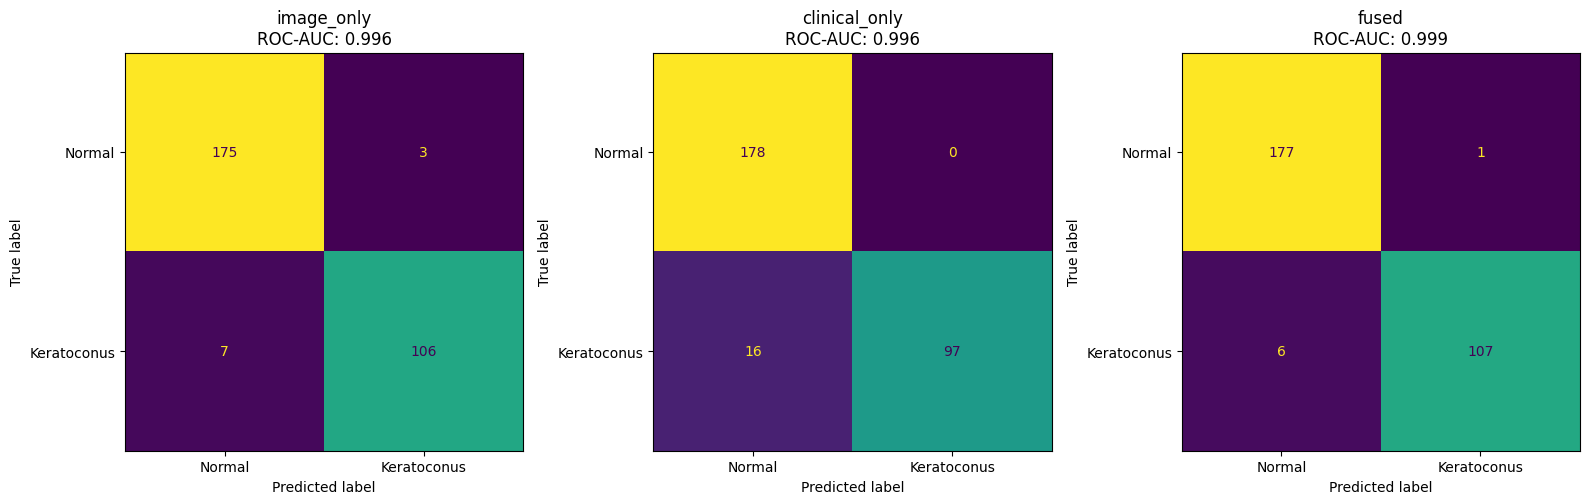

Saved → /content/CornOrb-Multimodal-KC/outputs/figures/confusion_matrices.png


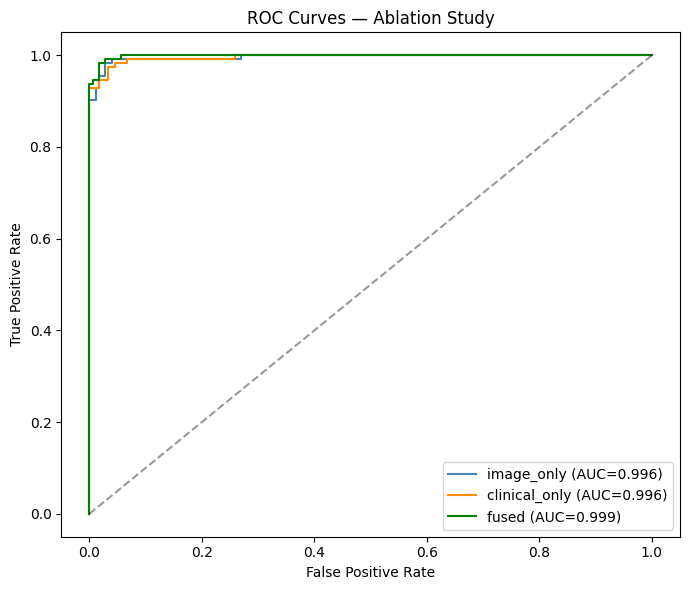

Saved → /content/CornOrb-Multimodal-KC/outputs/figures/roc_curves.png
         Mode  ROC-AUC  Accuracy  F1-macro  KC Recall
   image_only   0.9958    0.9656    0.9636     0.9381
clinical_only   0.9955    0.9450    0.9404     0.8584
        fused   0.9986    0.9759    0.9745     0.9469


In [13]:
from evaluation.metrics import (
    print_classification_reports,
    plot_training_curves,
    plot_confusion_matrices,
    plot_roc_curves,
    summary_table,
)

plot_training_curves(results)
print_classification_reports(results)
plot_confusion_matrices(results)
plot_roc_curves(results)
summary_table(results)


## 8. Error Analysis

Inspect the fused model's misclassified cases in detail.

- **`export_misclassified`** — exports a CSV of all wrongly predicted eyes to `outputs/`, including their clinical feature values, true and predicted labels, predicted KC probability, and error type (false negative / false positive).
- **`clinical_feature_comparison`** — compares mean and standard deviation of all seven clinical biomarkers between misclassified and correctly classified cases, helping identify whether errors cluster around atypical or borderline clinical profiles.

In [14]:
from evaluation.error_analysis import export_misclassified, clinical_feature_comparison

misclassified_df = export_misclassified(test_df, results, mode="fused")
clinical_feature_comparison(test_df, results, mode="fused")


Total misclassified: 7 / 291
error_type
False Negative (missed KC)         6
False Positive (over-called KC)    1
Name: count, dtype: int64
Saved → /content/CornOrb-Multimodal-KC/outputs/misclassified_fused_test.csv

CLINICAL FEATURE COMPARISON: Misclassified vs. Correct
              Feature  Misclassified_mean  Misclassified_std  Correct_mean  Correct_std  Mean_diff
            age_years               0.386              1.498        -0.016        0.979      0.402
        astig_value_D              -0.824              1.175         0.068        1.232     -0.891
         kmax_value_D               0.138              0.387         0.041        1.029      0.096
     pachy_central_um               0.225              1.016         0.197        0.974      0.028
    pachy_thinnest_um               0.086              1.187         0.174        1.038     -0.088
 asphericity_anterior               0.515              0.784         0.008        1.047      0.507
asphericity_posterior              

## 9. Grad-CAM Interpretability Analysis

Gradient-weighted Class Activation Mapping (Grad-CAM) is an interpretability technique that highlights the regions of an input image most influential to the model's prediction, by computing the gradient of the predicted class score with respect to the final convolutional feature maps. In this context, it reveals which corneal regions the model attends to when classifying an eye as Normal or Keratoconus across all four map types.

Four sets of visualizations are generated and saved to `outputs/figures/grad-cam/`:

- **Top 5 false negatives** — missed keratoconus eyes, showing where the model looked when it incorrectly predicted Normal.
- **Top 5 correct keratoconus detections** — confident true positives, showing the model's attention on established disease signatures.
- **False positive case(s)** — normal eyes incorrectly predicted as keratoconus, revealing which corneal features triggered a false alarm.
- **Top 5 correct normal detections** — confident true negatives, showing the model's recognition of healthy corneal patterns.

In [15]:
from evaluation.gradcam import run_gradcam_analysis

fused_model = results["fused"]["model"]
run_gradcam_analysis(fused_model, results, test_df, clinical_cols=CLINICAL_COLS, n_top=5)


Generating Grad-CAM for top 5 false negatives ...
Saved → /content/CornOrb-Multimodal-KC/outputs/figures/grad-cam/gradcam_error_ZRWCB_OS.png
Saved → /content/CornOrb-Multimodal-KC/outputs/figures/grad-cam/gradcam_error_ZRWCB_OD.png
Saved → /content/CornOrb-Multimodal-KC/outputs/figures/grad-cam/gradcam_error_54SR8_OD.png
Saved → /content/CornOrb-Multimodal-KC/outputs/figures/grad-cam/gradcam_error_RPE81_OD.png
Saved → /content/CornOrb-Multimodal-KC/outputs/figures/grad-cam/gradcam_error_G3H95_OD.png
Generating Grad-CAM for top 5 correct KC detections ...
Saved → /content/CornOrb-Multimodal-KC/outputs/figures/grad-cam/gradcam_correct_BHVFH_OS.png
Saved → /content/CornOrb-Multimodal-KC/outputs/figures/grad-cam/gradcam_correct_57Y9W_OD.png
Saved → /content/CornOrb-Multimodal-KC/outputs/figures/grad-cam/gradcam_correct_9WSDQ_OS.png
Saved → /content/CornOrb-Multimodal-KC/outputs/figures/grad-cam/gradcam_correct_URK1G_OD.png
Saved → /content/CornOrb-Multimodal-KC/outputs/figures/grad-cam/gra